# Perfect Foresight CRRA Model - Saving Rate

[![badge](https://img.shields.io/badge/Launch%20using%20-Econ--ARK-blue)](https://econ-ark.org/materials/perfforesightcrra-savingrate#launch)


This notebook demonstrates how to obtain the saving rate of a forward-looking consumer using HARK.

In [1]:
# Preliminaries

from HARK.ConsumptionSaving.ConsIndShockModel import (
    PerfForesightConsumerType,
)  # Import the consumer type
import matplotlib.pyplot as plt

import numpy as np


def mystr(number):
    return "{:.4f}".format(number)


# These last two will make our charts look nice
plt.style.use("seaborn-v0_8-darkgrid")
palette = plt.get_cmap("Dark2")

## 1. Creating an agent

We now import the HARK class that represents a perfect-foresight consumer with CRRA utility, and create an instance of it with the parameters we'd like.

In [63]:
# Set up a HARK Perfect Foresight Consumer called PFsavrate

# Now we need to "fill" our consumer with parameters that allow us to solve the consumer's problem

# First we need to set out a dictionary
ρ = CRRA = 2.0  # Coefficient of relative risk aversion
Rfree = 1.03  # Interest factor on assets
β = DiscFac = 0.97  # Intertemporal discount factor
LivPrb = [1.0]  # Survival probability
Γ = PermGroFac = [1.01]  # Permanent income growth factor
# Number of agents of this type (only matters for simulation# Number of periods in the cycle for this agent type
AgentCount = 1
cycles = 0  # Agent is infinitely lived
T_cycle = 1  # Every period is the same

# Make a dictionary to specify a perfect foresight consumer type
dict_wealth = {
    "CRRA": CRRA,
    "Rfree": [Rfree],
    "DiscFac": DiscFac,
    "LivPrb": LivPrb,
    "PermGroFac": PermGroFac,
    "AgentCount": AgentCount,
    "cycles": cycles,
    "T_cycle": T_cycle,
}


5.079207920792079


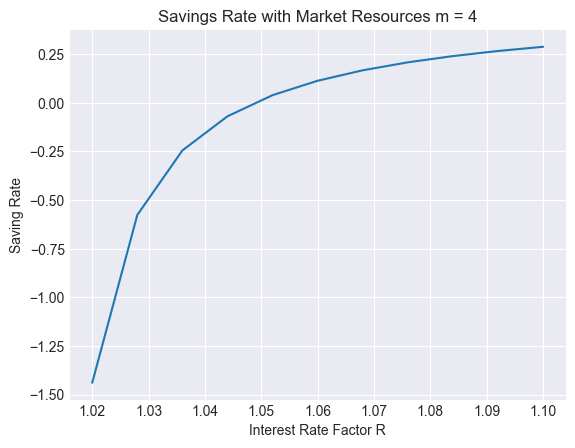

In [69]:
# Now lets pass our dictionary to our consumer class
PFsavrate = PerfForesightConsumerType(**dict_wealth)

# Create grid for r
a_tm1 = 4
r_array = np.linspace(1.02,1.10,11)

# Compute income components at every a
cap_income_t = np.outer(a_tm1,(r_array - 1)) / Γ
lab_income_t = 1

# and market resources
m_t = a_tm1 * Rfree / Γ[0] + 1

c_t = np.zeros(11)
# Consumption
for i in range(len(r_array)):
    PFsavrate.Rfree = [r_array[i]]
    PFsavrate.solve()
    c_t[i] = PFsavrate.solution[0].cFunc(m_t)

# and finally the saving rate
ς_t = sav_rate_t = (cap_income_t + lab_income_t - c_t) / (cap_income_t + lab_income_t)

# And now the plot
plt.plot(r_array,sav_rate_t.T)
plt.title("Savings Rate with Market Resources m = 4")
plt.xlabel("Interest Rate Factor R")
plt.ylabel("Saving Rate")

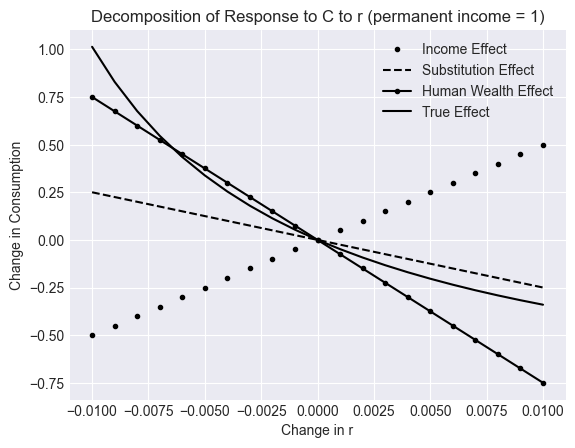

In [109]:
Rfree = 1.03
PermGroFac[0] = 1.01
r = Rfree - 1
g = PermGroFac[0] - 1
theta = 1 - DiscFac
IE = 1/(r-g)
SE = (-1/CRRA)*(1/(r-g))
HWE = -(r - (1/CRRA)*(r-theta))*(1/((r-g)**2))
TE = IE + SE + HWE

dr_array = np.linspace(-0.01,0.01,21)
r_array = dr_array + Rfree

true_array = np.zeros(21)
# Consumption
for i in range(len(r_array)):
    PFsavrate.Rfree = [r_array[i]]
    PFsavrate.solve()
    true_array[i] = PFsavrate.solution[0].cFunc(0)

true_array = true_array - true_array[10]
IE_array = IE*dr_array
SE_array = SE*dr_array
HWE_array = HWE*dr_array
TE_array = TE*dr_array


# And now the plot
plt.plot(dr_array,IE_array, '.k', label="Income Effect")
plt.plot(dr_array,SE_array, '--k', label="Substitution Effect")
plt.plot(dr_array,HWE_array, '.-k', label="Human Wealth Effect")
plt.plot(dr_array,true_array, '-k', label="Model Generated Total Effect")
plt.title("Decomposition of Response to C to r (permanent income = 1)")
plt.xlabel("Change in r")
plt.ylabel("Change in Consumption")
plt.legend()